In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

In [2]:
# RF01 – Criar/Carregar o Dataset de Vendas
def gerar_dataset_vendas(n_registros=200, seed=42):
    """Gera um dataset sintetico de vendas com dados sujos."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor",
                "Teclado", "Mouse", "Headset"]
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares",
                  "Tablet": "Celulares", "Monitor": "Computadores",
                  "Teclado": "Perifericos", "Mouse": "Perifericos",
                  "Headset": "Perifericos"}
    precos = {"Notebook": 3500, "Smartphone": 2200, "Tablet": 1800,
              "Monitor": 1200, "Teclado": 250, "Mouse": 120,
              "Headset": 350}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]

    data_inicio = datetime(2025, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        categoria = categorias[produto]
        quantidade = random.randint(1, 10)
        preco = round(precos[produto] * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))
        data_txt = data.strftime("%Y-%m-%d")
        cliente = f"Cliente_{random.randint(1, 50):03d}"

        # --- sujeira proposital para a etapa de limpeza ---
        if random.random() < 0.05:
            quantidade = None                    # valor nulo
        if random.random() < 0.04:
            preco = None                         # valor nulo
        if random.random() < 0.06:
            produto = "  " + produto + " "       # espacos extras
        if random.random() < 0.03:
            data_txt = "DATA INVALIDA"           # data invalida
        if random.random() < 0.10:
            cliente = random.choice([            # ruido no nome
                cliente.upper().replace("_", "-"),
                cliente + "!!",
                "  " + cliente,
                cliente.replace("Cliente_", "cliente#"),
            ])

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_txt,
            "cliente": cliente,
            "produto": produto,
            "categoria": categoria,
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco,
        })

    return pd.DataFrame(dados)


# Gerar e salvar o CSV bruto
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head())

Dataset gerado com 200 registros.
   id_venda  data_venda      cliente   produto     categoria        regiao  \
0         1  2025-05-21  cliente#016     Mouse   Perifericos       Sudeste   
1         2  2025-09-16  Cliente_039  Notebook  Computadores         Norte   
2         3  2025-03-23  Cliente_045    Tablet     Celulares  Centro-Oeste   
3         4  2025-11-06  Cliente_017  Notebook  Computadores         Norte   
4         5  2025-07-05  Cliente_037    Tablet     Celulares           Sul   

   quantidade  preco_unitario  
0         2.0          102.90  
1         NaN         3204.57  
2         1.0         1939.76  
3         6.0         3864.87  
4        10.0         2008.14  


In [3]:
# RF02 – Inspecionar e Descrever os Dados
def inspecionar_dados(df):
    """Exibe as informacoes estruturais do DataFrame."""
    print("\n=== INSPECAO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    return df

In [4]:
inspecionar_dados(df_bruto)



=== INSPECAO INICIAL DO DATASET ===
Shape: (200, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade        10
preco_unitario     4
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente   produto     categoria        regiao  \
0         1  2025-05-21  cliente#016     Mouse   Perifericos       Sudeste   
1         2  2025-09-16  Cliente_039  Notebook  Computadores         Norte   
2         3  2025-03-23  Cliente_045    Tablet     Celulares  Centro-Oeste   
3         4  2025-11-06  Cliente_017  Notebook  Comp

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2025-05-21,cliente#016,Mouse,Perifericos,Sudeste,2.0,102.90
1,2,2025-09-16,Cliente_039,Notebook,Computadores,Norte,NaN,3204.57
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14
...,...,...,...,...,...,...,...,...
195,196,2025-06-04,CLIENTE-038,Monitor,Computadores,Centro-Oeste,5.0,NaN
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3.0,1748.92
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3.0,2185.60
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4.0,368.94


In [5]:
# RF03 – Limpar e Tratar os Dados
import re

def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.
    Retorna: (df_limpo, relatorio), onde relatorio e um dicionario
    com as contagens de registros iniciais, removidos e finais.
    """
    df_limpo = df.copy()
    # 1. remover espacos extras nas colunas de texto
    df_limpo["produto"] = df_limpo["produto"].str.strip()
    df_limpo["categoria"] = df_limpo["categoria"].str.strip()
    df_limpo["regiao"] = df_limpo["regiao"].str.strip()
    df_limpo["cliente"] = df_limpo["cliente"].str.strip()
    # 2. converter data_venda e descartar datas invalidas
    df_limpo["data_venda"] = pd.to_datetime(df_limpo["data_venda"], errors="coerce")
    df_limpo = df_limpo.dropna(subset=["data_venda"])
    # 3. descartar nulos em quantidade e preco_unitario
    df_limpo = df_limpo.dropna(subset=["quantidade", "preco_unitario"])
    # 4. ajustar os tipos numericos
    df_limpo["quantidade"] = df_limpo["quantidade"].astype(int)
    df_limpo["preco_unitario"] = df_limpo["preco_unitario"].astype(float)
    # 5. padronizar o nome do cliente com re.sub() e re.compile()
    df_limpo["cliente"] = df_limpo["cliente"].apply( lambda x: re.sub(r'[^a-zA-Z0-9_]', '', str(x).strip()))
    df_limpo["cliente"] = df_limpo["cliente"].apply( lambda x: re.sub(r'(?i)cliente_?', 'Cliente_', x))
    # 6. montar e imprimir o relatorio de limpeza
    linhas_iniciais = len(df)
    linhas_finais = len(df_limpo)
    linhas_removidas = linhas_iniciais - linhas_finais

    relatorio = {
        "registros_iniciais": linhas_iniciais,
        "registros_removidos": linhas_removidas,
        "registros_finais": linhas_finais
        }
    return df_limpo, relatorio


In [6]:
# RF04 – Criar Colunas Derivadas com Transformações Condicionais
import numpy as np

def criar_colunas_derivadas(df) :
    """
    Cria novas colunas na planinlha para ajudar nas análises de venda.
    Recebe: df_limpo
    Retorna: df_derivado (DataFrame com as novas colunas)
    """
    df_derivado = df.copy()

    # 1 Calcular receita total de cada linha
    df_derivado["receita_total"] = df_derivado["quantidade"] * df_derivado["preco_unitario"]

    # 2 Extrair o ano e o número do mês da coluna de data
    df_derivado["ano"] = df_derivado["data_venda"].dt.year
    df_derivado["mes"] = df_derivado["data_venda"].dt.month

    # 3 Traduzir o número do mes para o nome em portugues
    dicionario_meses = { 1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril", 5: "Maio", 6: "Junho",
    7: "Julho", 8: "Agosto", 9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"}

    df_derivado["mes"] = df_derivado["mes"].map(dicionario_meses)

    # 4 Criar o trimestre mo formato q1-q4 (usando .dt.quarter e dicionário)
    df_derivado["trimestre"] = df_derivado["data_venda"].dt.quarter.map({1: "q1", 2: "q2", 3:"q3", 4: "q4"})

    #5 Classificação condicional da receita da linha com np.select
    condicoes = [
            df_derivado["receita_total"] < 500,
            (df_derivado["receita_total"] >= 500) & (df_derivado["receita_total"] < 5000),
            df_derivado["receita_total"] >= 5000,]
    faixas = ["Baixo Valor", "Medio Valor", "Alto Valor"]
    df_derivado["faixa_receita_item"] = np.select(condicoes, faixas, default="Nao Classificado")

    return df_derivado

In [7]:
# RF05 – Calcular Métricas Agregadas
def calcular_metricas(df) :
  """
  Calcula as métricas de vendas agrupadas por mês, produto, categoria e região.
  Retorna um dicionário contendo os DataFrames de cada análise.
  """
  # Criamos um dicionário vazio para guardar nossos resultados
  metricas = {}

  # 1. Métricas por Mês (Receita total, quantidade vendida e número de vendas)
  metricas["por_mes"] = df.groupby("mes").agg(
          receita_total=("receita_total", "sum"),
          quantidade_vendida=("quantidade", "sum"),
          n_vendas=("id_venda", "count")
      ).reset_index()

  # 2. Top 5 Produtos por Receita (em ordem decrescente)
  metricas["top_produtos"] = df.groupby("produto").agg(
          receita_total=("receita_total", "sum")
      ).sort_values(by="receita_total", ascending=False).head(5).reset_index()

  # 3. Receita Total por Categoria
  metricas["por_categoria"] = df.groupby("categoria").agg(
          receita_total=("receita_total", "sum")
      ).reset_index()

  # 4. Receita Total e Ticket Médio (média de gasto por venda) por Região
  metricas["por_regiao"] = df.groupby("regiao").agg(
          receita_total=("receita_total", "sum"),
          ticket_medio=("receita_total", "mean")
      ).reset_index()

  # Devolvemos os resultados prontos
  return metricas

In [8]:
# RF06 – Segmentar Clientes por Nível de Gasto
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, soma o faturamento total de cada um
    e os classifica em Bronze, Prata ou Ouro usando lambda.
    Retorna um DataFrame com cliente, total_gasto e segmento.
    """
    # 1. Agrupar por cliente e somar o faturamento total acumulado
    clientes_df = df.groupby("cliente")["receita_total"].sum().reset_index()

    # 2. Renomear a coluna para 'total_gasto' (exatamente como o professor pede)
    clientes_df = clientes_df.rename(columns={"receita_total": "total_gasto"})

    # 3. Classificar usando .apply() com a função lambda
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda valor: "Bronze" if valor < 5000
        else ("Prata" if valor <= 15000 else "Ouro")
    )

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)
    return clientes_df


In [9]:
# RF07 – Operações Numéricas com NumPy
def calcular_estatisticas_numpy(df):
    """Aplica operacoes NumPy sobre a coluna receita_total."""

    # 1. transformar a coluna em array NumPy
    receitas = df["receita_total"].to_numpy()

    # 2. funcoes de agregacao do NumPy (pelo menos 3 - aqui temos 6)
    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    total = np.sum(receitas)
    minimo = np.min(receitas)
    maximo = np.max(receitas)

    # 3. broadcasting: mesma conta aplicada em todos os valores de uma vez
    receitas_normalizadas = (receitas - minimo) / (maximo - minimo)

    # 4. filtragem booleana: so as vendas acima da media
    acima_da_media = receitas[receitas > media]

    # 5. mostrar os resultados
    print("Média:", media)
    print("Mediana:", mediana)
    print("Desvio padrão:", desvio_padrao)
    print("Total:", total)
    print("Mínimo:", minimo)
    print("Máximo:", maximo)
    print("Quantidade de vendas acima da média:", len(acima_da_media))

    # 6. devolver tudo organizado num dicionario, pra usar depois
    return {
        "media": media,
        "mediana": mediana,
        "desvio_padrao": desvio_padrao,
        "total": total,
        "minimo": minimo,
        "maximo": maximo,
        "qtd_acima_da_media": len(acima_da_media),
    }

In [10]:
# 1. Primeiro limpamos os dados brutos(df_bruto) para criar o df_limpo
df_limpo, relatorio = limpar_dados(df_bruto)

# 2. Agora com o df_limpo, criamos as colunas derivadas
df_limpo = criar_colunas_derivadas(df_limpo)

# 3. Caluculamos as estatísticas com numpy
estatisticas = calcular_estatisticas_numpy(df_limpo)

# 4. Segmentação de Clientes (Bronze, Prata, Ouro)
df_clientes = segmentar_clientes(df_limpo)

# 5. Mostrar os 10 maiores clientes (RF06)
print("\n--- TOP 10 MAIORES CLIENTES ---")
print(df_clientes.head(10))

# 6. Mostrar contagem por segmento
print("\n--- DISTRIBUIÇÃO POR SEGMENTO ---")
print(df_clientes["segmento"].value_counts())

Média: 7051.07267759563
Mediana: 3330.66
Desvio padrão: 7809.919232622955
Total: 1290346.3000000003
Mínimo: 104.19
Máximo: 38833.200000000004
Quantidade de vendas acima da média: 70

--- TOP 10 MAIORES CLIENTES ---
        cliente  total_gasto segmento
5   Cliente_006     65905.09     Ouro
35  Cliente_036     63433.04     Ouro
38  Cliente_039     59406.90     Ouro
19  Cliente_020     58459.54     Ouro
10  Cliente_011     56391.77     Ouro
33  Cliente_034     52035.60     Ouro
8   Cliente_009     50827.96     Ouro
23  Cliente_024     49146.94     Ouro
36  Cliente_037     46897.17     Ouro
18  Cliente_019     40731.05     Ouro

--- DISTRIBUIÇÃO POR SEGMENTO ---
segmento
Ouro      34
Prata     10
Bronze     6
Name: count, dtype: int64


In [11]:
# RF08 – Criar Visualizações com Matplotlib e Seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def criar_visualizacoes(df):
    """Gera e salva as visualizacoes obrigatorias do projeto (RF08)."""
    sns.set_theme(style="whitegrid")

    # 1. ORDENAR OS MESES CRONOLOGICAMENTE
    ordem_meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
                   'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

    df_mes = df.groupby("mes")["receita_total"].sum().reset_index()
    df_mes['mes'] = pd.Categorical(df_mes['mes'], categories=ordem_meses, ordered=True)
    df_mes = df_mes.sort_values('mes')

    # --- FIGURA 1: receita_por_mes.png ---
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_mes, x="mes", y="receita_total", marker="o", color="navy")
    plt.title("Receita Total por Mês")
    plt.xlabel("Mês")
    plt.ylabel("Receita (R$)")
    plt.xticks(rotation=45)
    sns.despine() # Remove bordas superior e direita (Requisito de boas praticas)
    plt.tight_layout()
    plt.savefig("receita_por_mes.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- FIGURA 2: top_produtos.png ---
    plt.figure(figsize=(10, 5))
    df_prod = df.groupby("produto")["receita_total"].sum().reset_index().sort_values("receita_total", ascending=False).head(5)
    sns.barplot(data=df_prod, x="produto", y="receita_total", hue="produto", legend=False, palette="viridis")
    plt.title("Top 5 Produtos por Receita")
    plt.xlabel("Produto")
    plt.ylabel("Receita Total (R$)")
    sns.despine()
    plt.tight_layout()
    plt.savefig("top_produtos.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- FIGURA 3: quantidade_vs_receita.png ---
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x="quantidade", y="receita_total", hue="categoria", s=100)
    plt.title("Quantidade vs. Receita Total por Categoria")
    plt.xlabel("Quantidade")
    plt.ylabel("Receita (R$)")
    sns.despine()
    plt.tight_layout()
    plt.savefig("quantidade_vs_receita.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- FIGURA 4: painel_resumo.png (Subplots 2x2) ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("SalesInsight PY - Painel Resumo", fontsize=16)

    # Subplot 1: Linha
    sns.lineplot(data=df_mes, x="mes", y="receita_total", ax=axes[0, 0], marker="o")
    axes[0, 0].set_title("Receita por Mês")
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Subplot 2: Barras
    sns.barplot(data=df_prod, x="produto", y="receita_total", ax=axes[0, 1], hue="produto", legend=False)
    axes[0, 1].set_title("Top 5 Produtos")

    # Subplot 3: Dispersão
    sns.scatterplot(data=df, x="quantidade", y="receita_total", hue="categoria", ax=axes[1, 0])
    axes[1, 0].set_title("Quantidade vs Receita")

    # Subplot 4: Região
    df_reg = df.groupby("regiao")["receita_total"].sum().reset_index()
    sns.barplot(data=df_reg, x="regiao", y="receita_total", ax=axes[1, 1], hue="regiao", legend=False)
    axes[1, 1].set_title("Receita por Região")

    # Remover bordas de todos os subplots
    for ax in axes.flat:
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("painel_resumo.png", dpi=150, bbox_inches="tight")
    plt.show()

In [12]:
# RF09 – Organizar o Código em Funções Reutilizáveis e em uma Classe
import pandas as pd
import numpy as np

# PARTE A: FUNÇÃO DE ORDEM SUPERIOR (RF09)
def aplicar_transformacao_coluna(df, nome_coluna, funcao_transformacao):
    """
    Funcao de Ordem Superior: Recebe outra funcao como argumento
    e a aplica em uma coluna do DataFrame usando .apply().
    """
    df_copia = df.copy()
    df_copia[nome_coluna] = df_copia[nome_coluna].apply(funcao_transformacao)
    return df_copia


# PARTE B: CLASSE ANALISADOR DE VENDAS (RF09)
class AnalisadorDeVendas:
    def __init__(self, caminho_arquivo):
        self.caminho_arquivo = caminho_arquivo
        self.df_bruto = None
        self.df_limpo = None
        self.clientes = None
        self.metricas = {}
        self.relatorio_limpeza = None

    def carregar(self):
        self.df_bruto = pd.read_csv(self.caminho_arquivo)
        print(f"[Analisador] {len(self.df_bruto)} registros lidos com sucesso.")

    def limpar(self):
        self.df_limpo, self.relatorio_limpeza = limpar_dados(self.df_bruto)
        print("[Analisador] Limpeza de dados realizada.")
        print(f"  Relatório de limpeza: {self.relatorio_limpeza}")

    def transformar(self):
        self.df_limpo = criar_colunas_derivadas(self.df_limpo)
        print("[Analisador] Colunas derivadas criadas.")

    def analisar(self):
        self.metricas['agregadas'] = calcular_metricas(self.df_limpo)
        self.metricas['estatisticas'] = calcular_estatisticas_numpy(self.df_limpo)
        self.clientes = segmentar_clientes(self.df_limpo)
        print("\n--- TOP 10 MAIORES CLIENTES ---")
        print(self.clientes.head(10))
        print("\n--- DISTRIBUIÇÃO POR SEGMENTO ---")
        print(self.clientes["segmento"].value_counts())
        print("[Analisador] Análise estatística e segmentação concluídas.")

    def visualizar(self):
        criar_visualizacoes(self.df_limpo)
        print("[Analisador] Visualizações geradas.")

    def resumo(self):
        receita = self.metricas.get('estatisticas', {}).get('total', 0.0)
        print("\n" + "=" * 55)
        print("          RESUMO EXECUTIVO DO ANALISADOR")
        print("=" * 55)
        print(f"Total de Registros Brutos: {len(self.df_bruto)}")
        print(f"Total de Registros Limpos: {len(self.df_limpo)}")
        print(f"Clientes Segmentados:     {len(self.clientes)}")
        print(f"Receita Total:            R$ {receita:,.2f}")
        print("=" * 55)

   SALESINSIGHT PY - Análise de Dados de Vendas
[Analisador] 200 registros lidos com sucesso.
[Analisador] Limpeza de dados realizada.
  Relatório de limpeza: {'registros_iniciais': 200, 'registros_removidos': 17, 'registros_finais': 183}
[Analisador] Colunas derivadas criadas.
Média: 7051.07267759563
Mediana: 3330.66
Desvio padrão: 7809.919232622955
Total: 1290346.3000000003
Mínimo: 104.19
Máximo: 38833.200000000004
Quantidade de vendas acima da média: 70

--- TOP 10 MAIORES CLIENTES ---
        cliente  total_gasto segmento
5   Cliente_006     65905.09     Ouro
35  Cliente_036     63433.04     Ouro
38  Cliente_039     59406.90     Ouro
19  Cliente_020     58459.54     Ouro
10  Cliente_011     56391.77     Ouro
33  Cliente_034     52035.60     Ouro
8   Cliente_009     50827.96     Ouro
23  Cliente_024     49146.94     Ouro
36  Cliente_037     46897.17     Ouro
18  Cliente_019     40731.05     Ouro

--- DISTRIBUIÇÃO POR SEGMENTO ---
segmento
Ouro      34
Prata     10
Bronze     6
Name:

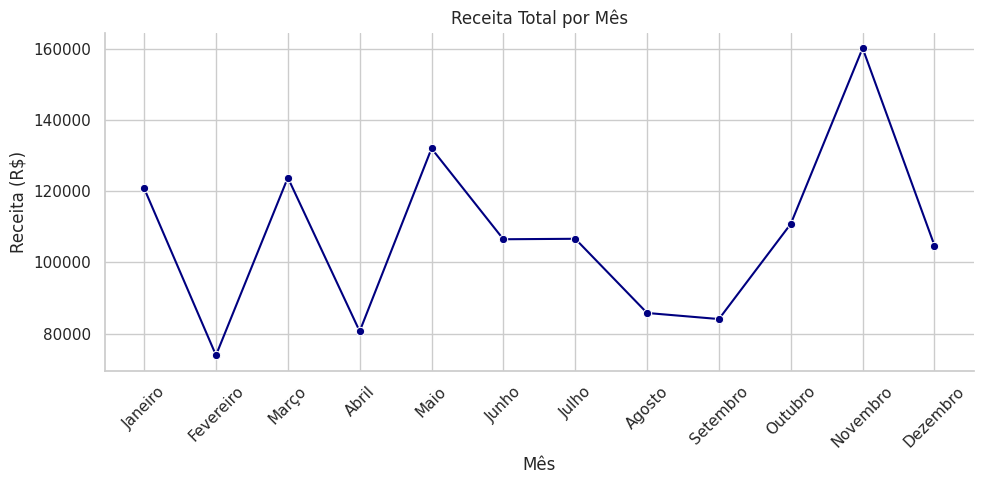

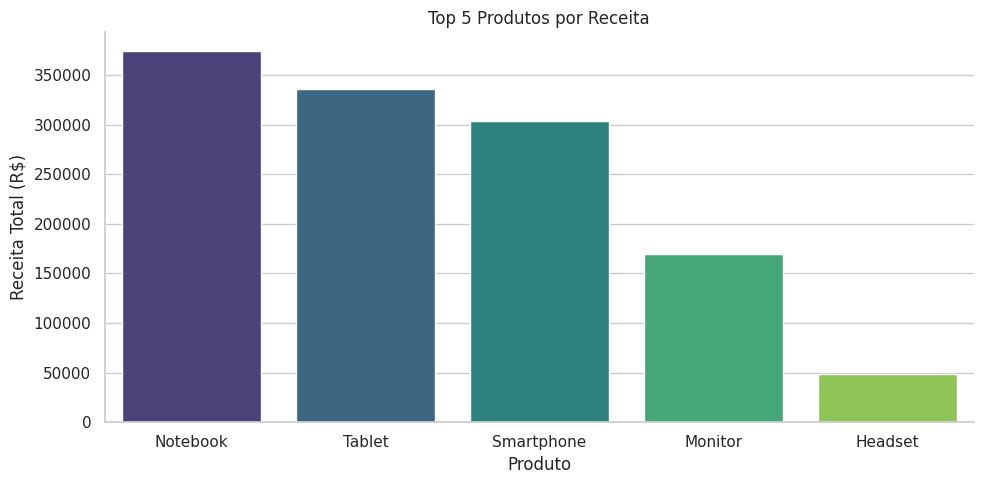

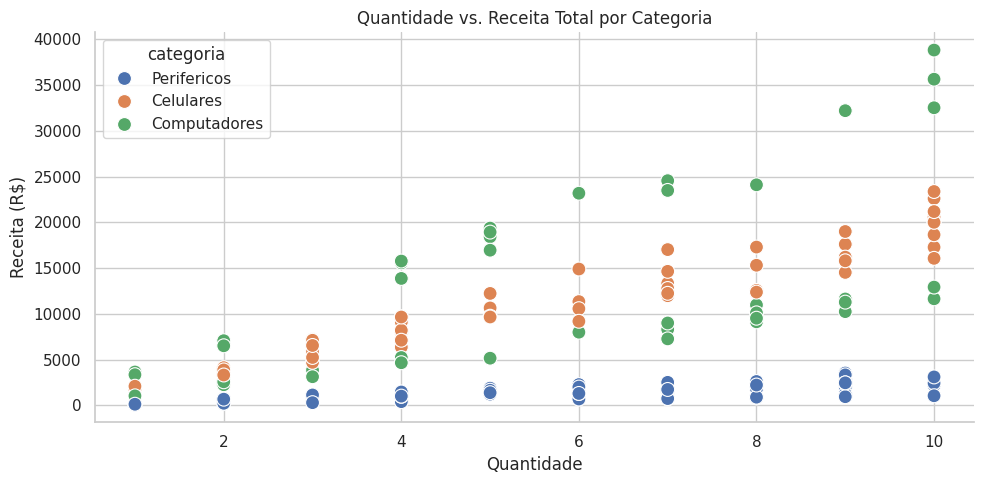

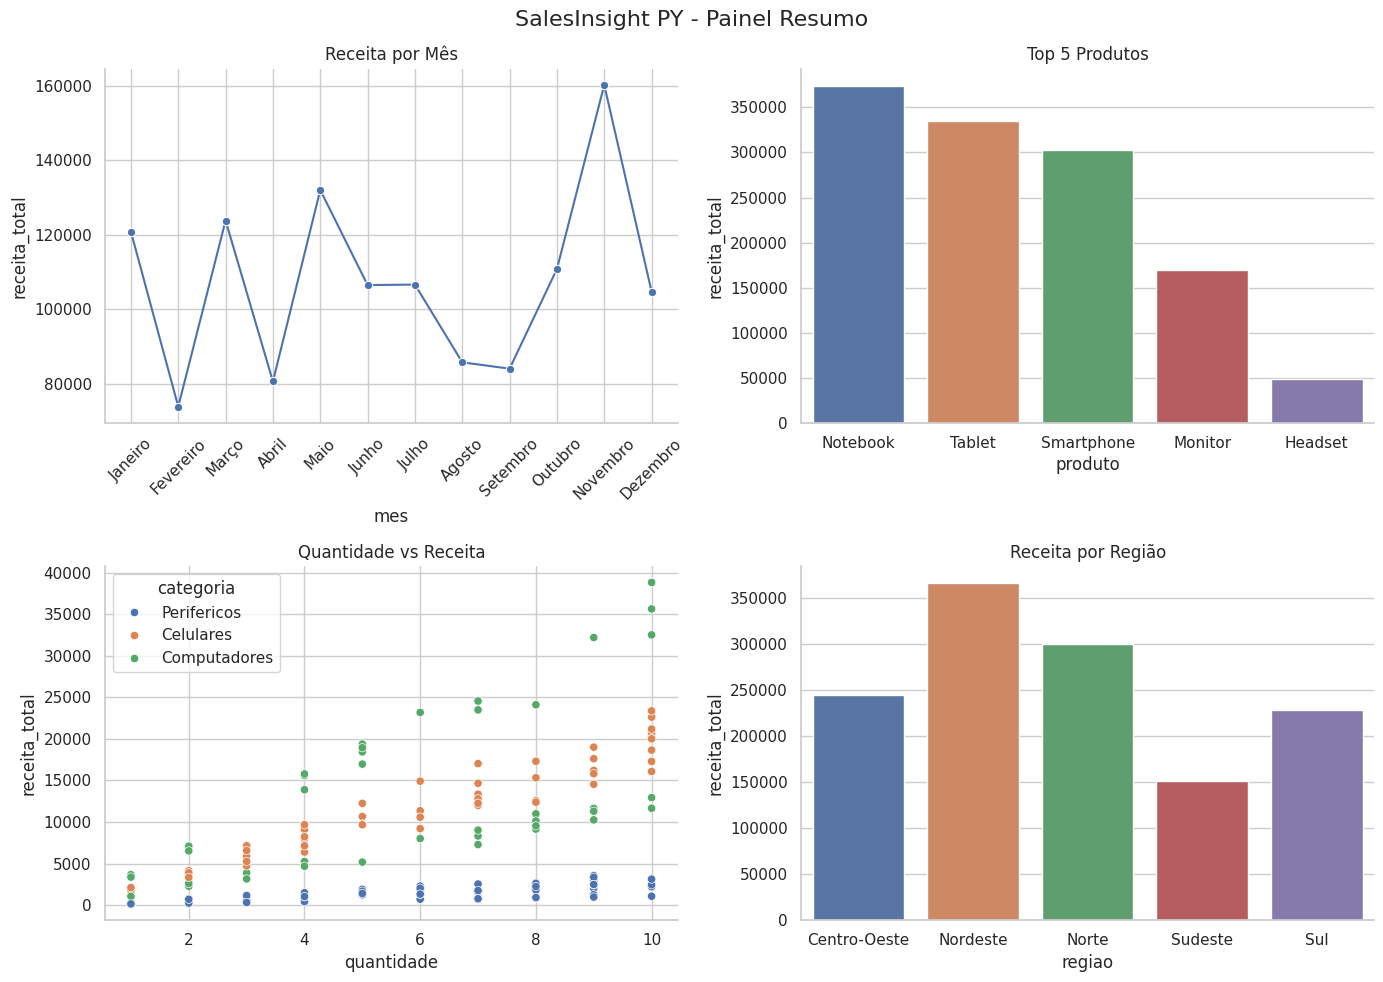

[Analisador] Visualizações geradas.

          RESUMO EXECUTIVO DO ANALISADOR
Total de Registros Brutos: 200
Total de Registros Limpos: 183
Clientes Segmentados:     50
Receita Total:            R$ 1,290,346.30

[Demo função de ordem superior] categorias em maiúsculo: ['PERIFERICOS' 'CELULARES' 'COMPUTADORES']

[OK] Arquivo JSON exportado e verificado: {'media': 7051.07, 'mediana': 3330.66, 'desvio_padrao': 7809.92, 'total': 1290346.3, 'minimo': 104.19, 'maximo': 38833.2, 'qtd_acima_da_media': 70.0}

[CONCLUÍDO] Projeto executado com sucesso!


In [13]:
# RF10 – Exportar Resultados em CSV e JSON
import os
import json

def exportar_resultados(metricas, clientes, estatisticas):
    """Exporta os resultados processados para a pasta outputs (RF10)."""
    os.makedirs("outputs", exist_ok=True)

    if isinstance(metricas, pd.DataFrame):
        metricas.to_csv("outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig")
    if isinstance(clientes, pd.DataFrame):
        clientes.to_csv("outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig")

    serializavel = {k: round(float(v), 2) for k, v in estatisticas.items()}
    caminho_json = "outputs/estatisticas_gerais.json"

    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(serializavel, f, indent=4, ensure_ascii=False)

    with open(caminho_json, "r", encoding="utf-8") as f:
        conferencia = json.load(f)
        print(f"\n[OK] Arquivo JSON exportado e verificado: {conferencia}")

# RF11 – Executar o Fluxo Completo
def main():
    """Executa o fluxo completo do SalesInsight PY (RF11)."""
    print("=" * 60)
    print("   SALESINSIGHT PY - Análise de Dados de Vendas")
    print("=" * 60)

    analisador = AnalisadorDeVendas("vendas.csv")
    analisador.carregar()
    analisador.limpar()
    analisador.transformar()
    analisador.analisar()
    analisador.visualizar()
    analisador.resumo()

    df_maiusculo = aplicar_transformacao_coluna(
        analisador.df_limpo, "categoria", lambda x: x.upper()
    )
    print("\n[Demo função de ordem superior] categorias em maiúsculo:",
          df_maiusculo["categoria"].unique())

    df_mes = analisador.metricas['agregadas']['por_mes']
    exportar_resultados(df_mes, analisador.clientes, analisador.metricas['estatisticas'])

    print("\n[CONCLUÍDO] Projeto executado com sucesso!")


if __name__ == "__main__":
    main()